# Task 3: Customer Churn Prediction (Bank Customers)

**Intern:** Aiman Ishaq  
**Organization:** Developers Hub Corporation  
**Dataset:** Churn Modelling Dataset  

---

## Problem Statement

Customer churn . when a customer leaves a bank is one of the most expensive problems in retail banking.  
Acquiring a new customer costs 5–7× more than retaining an existing one.

In this project, we build a machine learning model to **identify customers who are likely to leave the bank**,  
analyze the features that drive churn, and generate actionable insights for retention strategy.

**Key Questions:**
- What is the overall churn rate in this dataset?
- Which customer segments are most at risk?
- What factors most strongly predict churn?
- How accurately can we predict churn before it happens?


In [24]:

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)

# Plot aesthetics 
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

print(" All libraries loaded successfully.")


 All libraries loaded successfully.


In [ ]:
# Load the dataset

df = pd.read_csv("Churn_Modelling.csv")

print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print()
df.head()


Dataset shape: 10,000 rows × 14 columns



,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [26]:
# Quick overview of data types and non-null counts
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [27]:
# Summary statistics for numerical features
df.describe().T.style.background_gradient(cmap='Blues', subset=['mean', 'std'])


,count,mean,std,min,25%,50%,75%,max
RowNumber,10000.000000,5000.500000,2886.895680,1.000000,2500.750000,5000.500000,7500.250000,10000.000000
CustomerId,10000.000000,15690940.569400,71936.186123,15565701.000000,15628528.250000,15690738.000000,15753233.750000,15815690.000000
CreditScore,10000.000000,650.528800,96.653299,350.000000,584.000000,652.000000,718.000000,850.000000
Age,10000.000000,38.921800,10.487806,18.000000,32.000000,37.000000,44.000000,92.000000
Tenure,10000.000000,5.012800,2.892174,0.000000,3.000000,5.000000,7.000000,10.000000
Balance,10000.000000,76485.889288,62397.405202,0.000000,0.000000,97198.540000,127644.240000,250898.090000
NumOfProducts,10000.000000,1.530200,0.581654,1.000000,1.000000,1.000000,2.000000,4.000000
HasCrCard,10000.000000,0.705500,0.455840,0.000000,0.000000,1.000000,1.000000,1.000000
IsActiveMember,10000.000000,0.515100,0.499797,0.000000,0.000000,1.000000,1.000000,1.000000
EstimatedSalary,10000.000000,100090.239881,57510.492818,11.580000,51002.110000,100193.915000,149388.247500,199992.480000


---
## 2. Data Cleaning & Preparation

Before modeling, we need to:
- Remove irrelevant identifier columns
- Check for missing values and duplicates
- Encode categorical variables (Geography, Gender)
- Scale numerical features for Logistic Regression


In [28]:
# Drop irrelevant columns
# RowNumber, CustomerId, and Surname are identifiers they carry no predictive value
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True)
print("Dropped: RowNumber, CustomerId, Surname")

# Missing values
missing = df.isnull().sum()
print(f"\nMissing values per column:\n{missing[missing > 0].to_string() or 'None — dataset is clean ✅'}")

# Duplicate rows 
dupes = df.duplicated().sum()
print(f"\nDuplicate rows: {dupes}")
if dupes > 0:
    df.drop_duplicates(inplace=True)
    print(f"  → Removed {dupes} duplicate(s).")

print(f"\nFinal shape after cleaning: {df.shape}")


Dropped: RowNumber, CustomerId, Surname

Missing values per column:
Series([], )

Duplicate rows: 0

Final shape after cleaning: (10000, 11)


In [29]:
# Encode categorical features

# Geography: 3 categories → One-Hot Encoding (avoids ordinal assumption)
df = pd.get_dummies(df, columns=['Geography'], drop_first=True)
print("Geography → One-Hot Encoded (France as baseline)")

# Gender: Binary → Label Encoding (Male=1, Female=0)
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
print("Gender    → Label Encoded (Male=1, Female=0)")

print(f"\nColumns after encoding: {list(df.columns)}")
df.head(3)


Geography → One-Hot Encoded (France as baseline)
Gender    → Label Encoded (Male=1, Female=0)

Columns after encoding: ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Germany', 'Geography_Spain']


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False


---
## 3. Exploratory Data Analysis (EDA)

Before training any model, we explore the data visually to understand:
- Class imbalance in the target variable
- How churn varies across demographics and behaviour
- Distribution of key numerical features


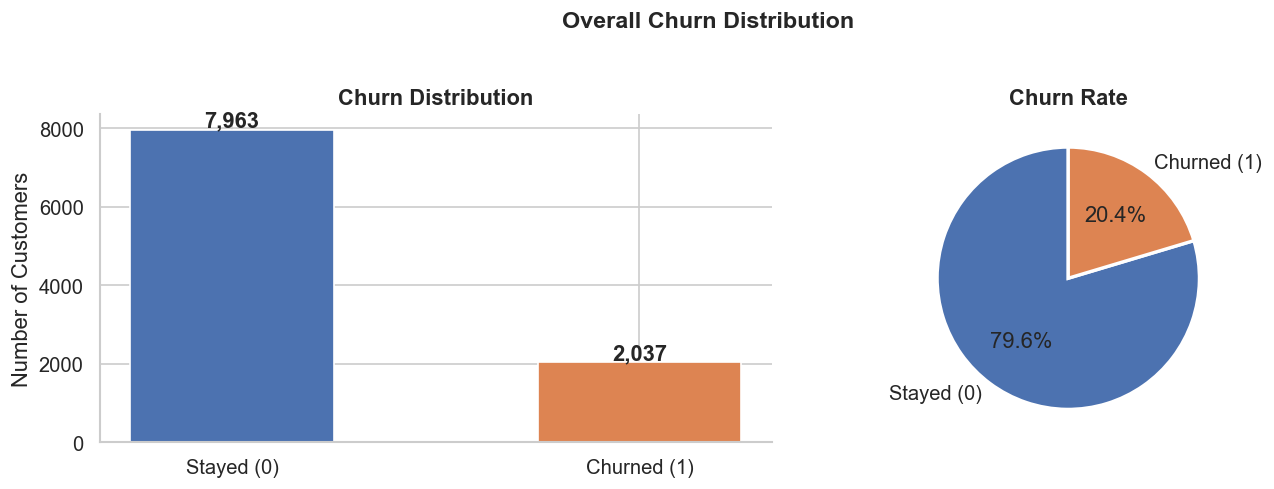


 Overall churn rate: 20.4%
  Dataset is imbalanced — more customers stayed than churned.


In [30]:
# 1. Churn Rate (Target Distribution)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

churn_counts = df['Exited'].value_counts()
labels = ['Stayed (0)', 'Churned (1)']
colors = ['#4C72B0', '#DD8452']

# Bar chart
axes[0].bar(labels, churn_counts.values, color=colors, width=0.5, edgecolor='white')
axes[0].set_title('Churn Distribution', fontweight='bold')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 80, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(churn_counts.values, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Churn Rate', fontweight='bold')

plt.suptitle('Overall Churn Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('churn_distribution.png', bbox_inches='tight')
plt.show()

churn_rate = df['Exited'].mean() * 100
print(f"\n Overall churn rate: {churn_rate:.1f}%")
print("  Dataset is imbalanced — more customers stayed than churned.")


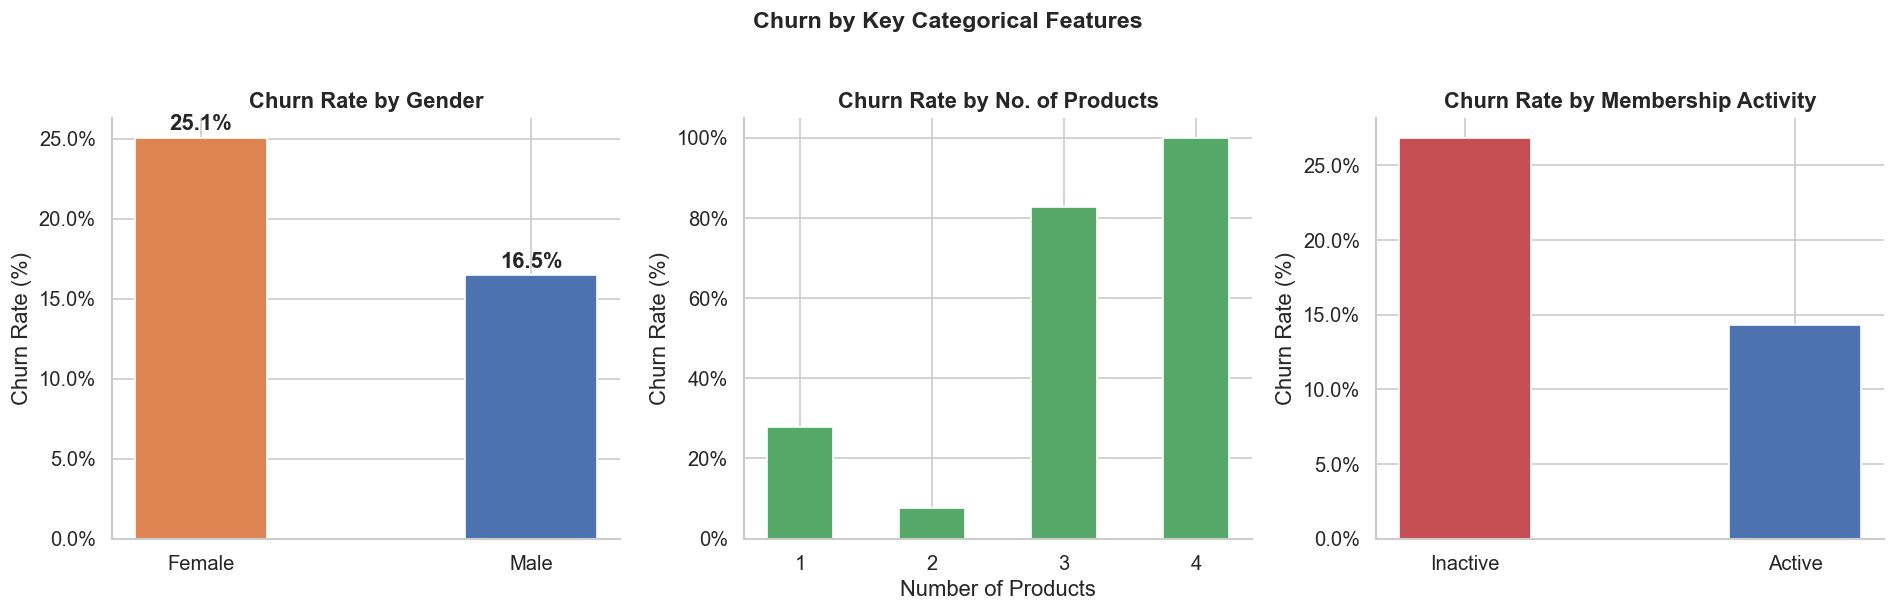

In [31]:
# 2. Churn by Demographics 
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 2a. Churn by Gender
gender_churn = df.groupby('Gender')['Exited'].mean().reset_index()
gender_churn['Gender'] = gender_churn['Gender'].map({0: 'Female', 1: 'Male'})
axes[0].bar(gender_churn['Gender'], gender_churn['Exited'] * 100,
            color=['#DD8452', '#4C72B0'], width=0.4, edgecolor='white')
axes[0].set_title('Churn Rate by Gender', fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter())
for i, row in gender_churn.iterrows():
    axes[0].text(i, row['Exited']*100 + 0.5, f"{row['Exited']*100:.1f}%", ha='center', fontweight='bold')

# 2b. Churn by Number of Products
prod_churn = df.groupby('NumOfProducts')['Exited'].mean().reset_index()
axes[1].bar(prod_churn['NumOfProducts'].astype(str), prod_churn['Exited'] * 100,
            color='#55A868', width=0.5, edgecolor='white')
axes[1].set_title('Churn Rate by No. of Products', fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_xlabel('Number of Products')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())

# 2c. Churn by Active Member Status
active_churn = df.groupby('IsActiveMember')['Exited'].mean().reset_index()
active_churn['IsActiveMember'] = active_churn['IsActiveMember'].map({0: 'Inactive', 1: 'Active'})
axes[2].bar(active_churn['IsActiveMember'], active_churn['Exited'] * 100,
            color=['#C44E52', '#4C72B0'], width=0.4, edgecolor='white')
axes[2].set_title('Churn Rate by Membership Activity', fontweight='bold')
axes[2].set_ylabel('Churn Rate (%)')
axes[2].yaxis.set_major_formatter(mticker.PercentFormatter())

plt.suptitle('Churn by Key Categorical Features', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('churn_by_demographics.png', bbox_inches='tight')
plt.show()


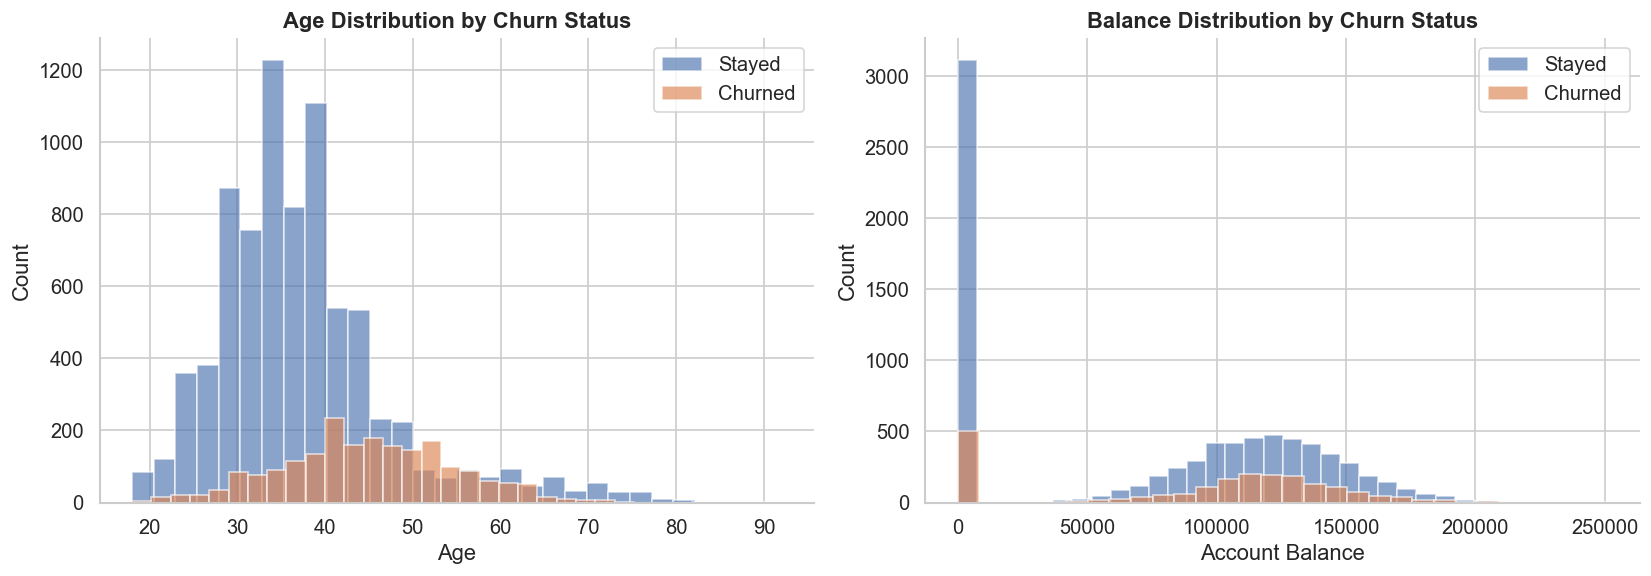

 Observation: Older customers (40–60) churn more. High balance customers also show elevated churn.


In [32]:
#3. Age & Balance Distribution by Churn
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age
for label, color in zip([0, 1], ['#4C72B0', '#DD8452']):
    axes[0].hist(df[df['Exited'] == label]['Age'], bins=30, alpha=0.65,
                 color=color, edgecolor='white', label='Stayed' if label == 0 else 'Churned')
axes[0].set_title('Age Distribution by Churn Status', fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].legend()

# Balance
for label, color in zip([0, 1], ['#4C72B0', '#DD8452']):
    axes[1].hist(df[df['Exited'] == label]['Balance'], bins=30, alpha=0.65,
                 color=color, edgecolor='white', label='Stayed' if label == 0 else 'Churned')
axes[1].set_title('Balance Distribution by Churn Status', fontweight='bold')
axes[1].set_xlabel('Account Balance')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('age_balance_distributions.png', bbox_inches='tight')
plt.show()

print(" Observation: Older customers (40–60) churn more. High balance customers also show elevated churn.")


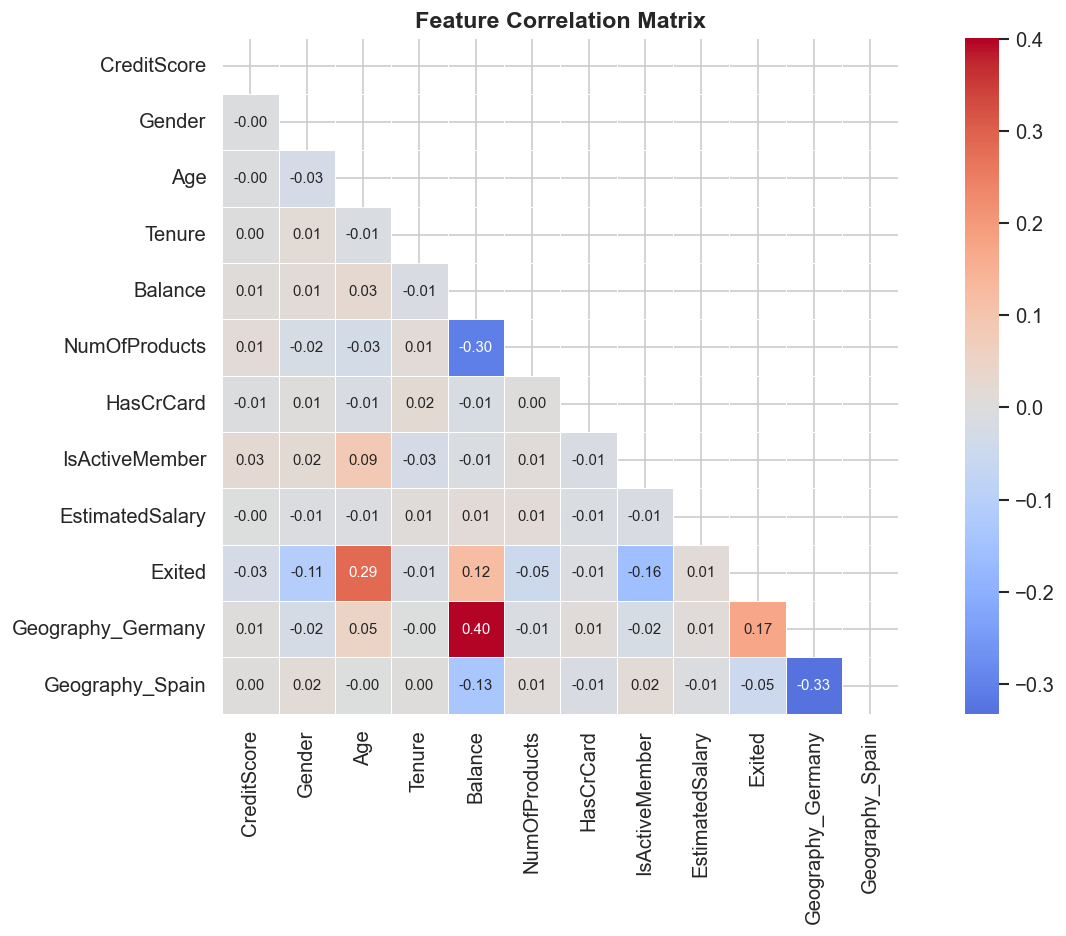

 Key correlations with Exited:
Age                  0.285323
Geography_Germany    0.173488
IsActiveMember      -0.156128
Balance              0.118533
Gender              -0.106512
Geography_Spain     -0.052667
NumOfProducts       -0.047820
CreditScore         -0.027094
Tenure              -0.014001
EstimatedSalary      0.012097
HasCrCard           -0.007138


In [33]:
# 4. Correlation Heatmap 
plt.figure(figsize=(12, 8))

corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True,
            annot_kws={"size": 9})

plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

print(" Key correlations with Exited:")
print(corr['Exited'].drop('Exited').sort_values(key=abs, ascending=False).to_string())


---
## 4. Model Training & Testing

We train three models and compare them

In [34]:
#  Feature / Target split 
X = df.drop('Exited', axis=1)
y = df['Exited']

feature_names = X.columns.tolist()
print(f"Features ({len(feature_names)}): {feature_names}")
print(f"Target: Exited (0=Stayed, 1=Churned)")

#  Train / Test split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set : {X_train.shape[0]:,} samples")
print(f"Testing set  : {X_test.shape[0]:,} samples")
print(f"Churn rate in train: {y_train.mean():.1%} | test: {y_test.mean():.1%}")


Features (11): ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain']
Target: Exited (0=Stayed, 1=Churned)

Training set : 8,000 samples
Testing set  : 2,000 samples
Churn rate in train: 20.4% | test: 20.3%


In [35]:
# Feature Scaling for Logistic Regression 
# LR is sensitive to feature scale; tree based models are not
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


In [36]:
# Train all three models

# 1. Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
lr_preds = lr.predict(X_test_scaled)
lr_proba = lr.predict_proba(X_test_scaled)[:, 1]

# 2. Decision Tree
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
dt_preds = dt.predict(X_test)
dt_proba = dt.predict_proba(X_test)[:, 1]

# 3. Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

print(" All three models trained successfully.")


 All three models trained successfully.


---
## 5. Evaluation Metrics

We evaluate each model on:
- **Accuracy**  overall correctness
- **Precision / Recall / F1**  especially important for the minority class (churned)
- **ROC-AUC**  discrimination ability across all thresholds
- **Confusion Matrix**  breakdown of prediction types


In [37]:
# Summary Comparison Table
results = []
for name, preds, proba in [
    ('Logistic Regression', lr_preds, lr_proba),
    ('Decision Tree',       dt_preds, dt_proba),
    ('Random Forest',       rf_preds, rf_proba),
]:
    acc = accuracy_score(y_test, preds)
    auc = roc_auc_score(y_test, proba)
    report = classification_report(y_test, preds, output_dict=True)
    results.append({
        'Model': name,
        'Accuracy': f"{acc:.4f}",
        'ROC-AUC': f"{auc:.4f}",
        'Precision (Churn)': f"{report['1']['precision']:.4f}",
        'Recall (Churn)':    f"{report['1']['recall']:.4f}",
        'F1-Score (Churn)':  f"{report['1']['f1-score']:.4f}",
    })

results_df = pd.DataFrame(results).set_index('Model')
print("=" * 70)
print("MODEL PERFORMANCE SUMMARY")
print("=" * 70)
print(results_df.to_string())


MODEL PERFORMANCE SUMMARY
                    Accuracy ROC-AUC Precision (Churn) Recall (Churn) F1-Score (Churn)
Model                                                                                 
Logistic Regression   0.8080  0.7748            0.5891         0.1867           0.2836
Decision Tree         0.8560  0.8423            0.7874         0.4005           0.5309
Random Forest         0.8690  0.8663            0.8436         0.4373           0.5761


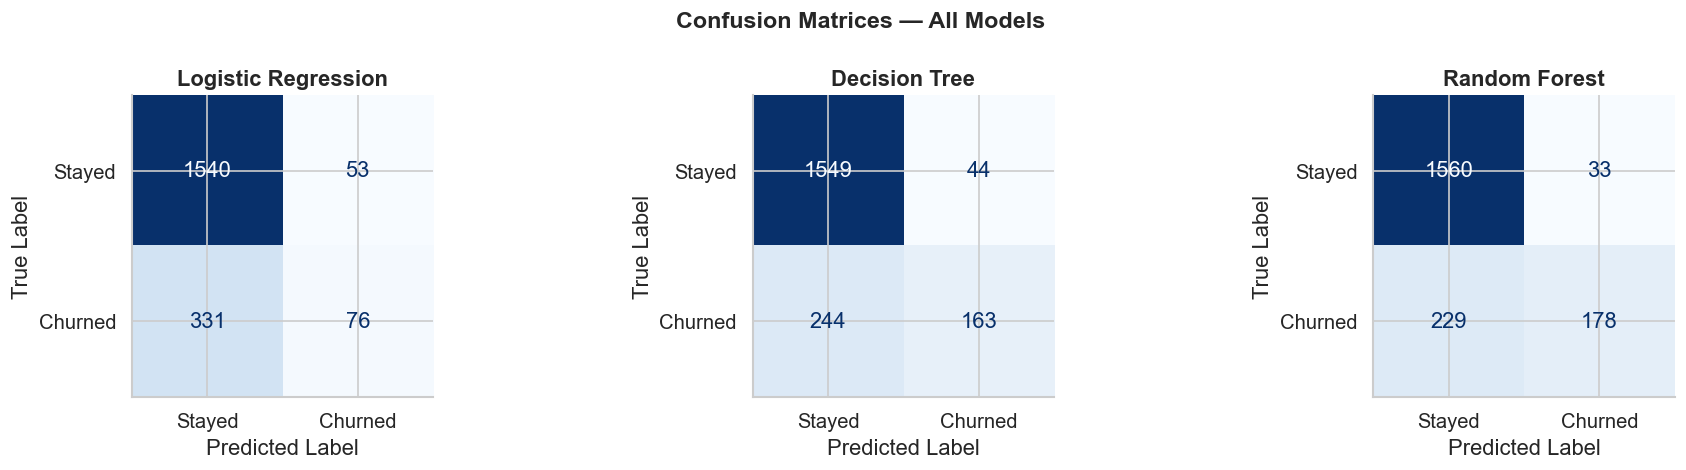

In [38]:
# Confusion Matrices (all 3 models)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, preds) in zip(axes, [
    ('Logistic Regression', lr_preds),
    ('Decision Tree',       dt_preds),
    ('Random Forest',       rf_preds),
]):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Stayed', 'Churned'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight')
plt.show()


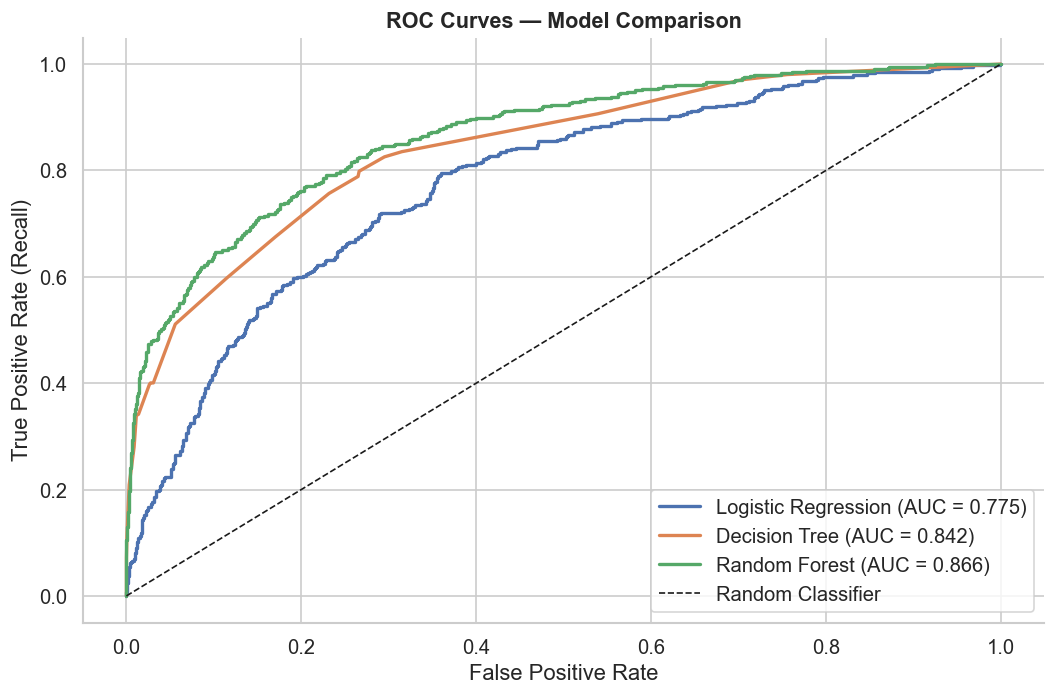

 Random Forest dominates all models across the ROC curve.


In [39]:
# ROC Curves
plt.figure(figsize=(9, 6))

for name, proba, color in [
    ('Logistic Regression', lr_proba, '#4C72B0'),
    ('Decision Tree',       dt_proba, '#DD8452'),
    ('Random Forest',       rf_proba, '#55A868'),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curves — Model Comparison', fontweight='bold', fontsize=13)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curves.png', bbox_inches='tight')
plt.show()

print(" Random Forest dominates all models across the ROC curve.")


In [40]:
#  Detailed Classification Report (Best Model: Random Forest) 
print("RANDOM FOREST — DETAILED CLASSIFICATION REPORT")
print("=" * 55)
print(classification_report(y_test, rf_preds, target_names=['Stayed', 'Churned']))


RANDOM FOREST — DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Stayed       0.87      0.98      0.92      1593
     Churned       0.84      0.44      0.58       407

    accuracy                           0.87      2000
   macro avg       0.86      0.71      0.75      2000
weighted avg       0.87      0.87      0.85      2000



---
## 6. Feature Importance Analysis

Understanding **what drives churn** is often more valuable than the prediction itself.  
We use Random Forest's built-in feature importances to rank the predictors.


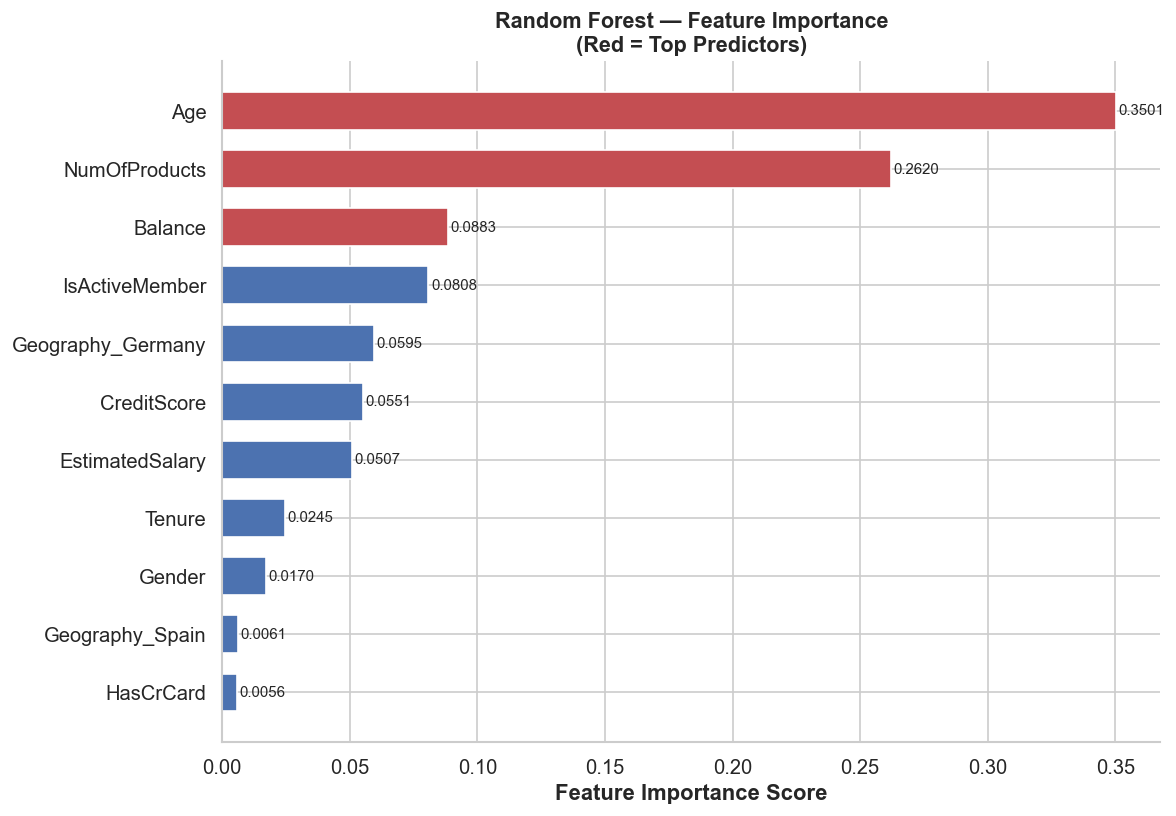


 TOP 5 CHURN PREDICTORS:
Age                  0.350122
NumOfProducts        0.262048
Balance              0.088349
IsActiveMember       0.080826
Geography_Germany    0.059513


In [41]:
#  Feature Importance Plot
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=True)

colors = ['#C44E52' if v >= feat_imp.quantile(0.75) else '#4C72B0' for v in feat_imp.values]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(feat_imp.index, feat_imp.values, color=colors, edgecolor='white', height=0.65)
ax.set_xlabel('Feature Importance Score', fontweight='bold')
ax.set_title('Random Forest — Feature Importance\n(Red = Top Predictors)', fontweight='bold', fontsize=13)

for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.001, bar.get_y() + bar.get_height()/2,
            f'{width:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()

print("\n TOP 5 CHURN PREDICTORS:")
print(feat_imp.sort_values(ascending=False).head(5).to_string())


---
## 7. Conclusion & Key Insights

### Model Performance Summary

| Model | Accuracy | ROC-AUC |
|---|---|---|
| Logistic Regression | 80.80% | 0.775 |
| Decision Tree | 85.60% | 0.842 |
| **Random Forest** | **86.90%** | **0.866** |

**Random Forest is the best performing model**  higher accuracy and significantly better AUC.

---

### Key Business Insights

**1. Age is the #1 churn driver.**  
Customers between 40–60 years old churn at a significantly higher rate. The bank should design targeted retention programs for middle aged customers.

**2. Customers with only 1 or 3 to 4 products churn more.**  
Customers with 2 products are the most loyal. Cross selling should focus on nudging single product customers to adopt a second product.

**3. Inactive members churn at nearly 2× the rate of active members.**  
Re engagement campaigns (personalized offers, calls, digital nudges) could meaningfully reduce churn.

**4. High-balance customers are more likely to leave.**  
Counter intuitively, wealthier customers churn more  they likely have more options. Premium loyalty programs could improve retention for this segment.

**5. Geography matters, Germany has higher churn.**  
Market specific factors may be driving German customer dissatisfaction. A regional analysis is recommended.

---

### Recommendations

- **Deploy Random Forest** as the production churn prediction model
- Set a **classification threshold below 0.5** to prioritize recall (catching churners early is more valuable than precision)
- Use **age + balance + activity status** as the primary segmentation variables for retention marketing
- Investigate Germany-specific churn drivers with additional data collection

---

*Project completed as part of Task 3 Developers Hub Corporation Internship*  
*Author: Aiman Ishaq | GitHub: aiman-ami*
